In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms

from transformers import SwinForImageClassification, SwinConfig

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from dataset import APTOSDataset, IDRiDDataset

from PIL import Image
import os

from torch.optim.lr_scheduler import CosineAnnealingLR

In [2]:
csv_path = "aptos_dataset/train.csv"
image_dir = "aptos_dataset/train_images"

df = pd.read_csv(csv_path)

In [3]:
# Create ordinal thresholds for each label
def make_thresholds(label):
    return [1 if label >= i else 0 for i in range(1, 5)]

df['thresholds'] = df['diagnosis'].apply(make_thresholds)

In [4]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['diagnosis'],
    random_state=78
)

In [29]:
def crop_fundus(image):
    gray = np.array(image.convert('L'))
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        image = image.crop((x, y, x + w, y + h))
    
    return image

In [30]:
class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_side = max(w, h)
        pad_left = (max_side - w) // 2
        pad_top = (max_side - h) // 2
        padding = (pad_left, pad_top, max_side - w - pad_left, max_side - h - pad_top)
        return transforms.functional.pad(image, padding, fill=0)

In [31]:
transform_train = transforms.Compose([
    transforms.Lambda(crop_fundus),
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

In [32]:
transform_val = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [33]:
train_dataset = APTOSDataset(train_df, image_dir, transform_train)
val_dataset = APTOSDataset(val_df, image_dir, transform_val)

In [34]:
class_counts_tr = train_df['diagnosis'].value_counts().sort_index().values
class_counts_vl = val_df['diagnosis'].value_counts().sort_index().values

print(train_df.shape)
print(val_df.shape)
print(f"Class counts of train set: {class_counts_tr}")
print(f"Class counts of val set: {class_counts_vl}")

(2929, 3)
(733, 3)
Class counts of train set: [1444  296  799  154  236]
Class counts of val set: [361  74 200  39  59]


In [35]:
class_weights = 1. / class_counts_tr
sample_weights = torch.tensor(
    train_df['diagnosis'].map(
        {i: class_weights[i] for i in range(len(class_weights))}
    ).values,
    dtype=torch.float
)

sampler = WeightedRandomSampler(
    weights = sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [36]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler = sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle = False
)

In [37]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Unique labels in batch:", labels.unique())

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32, 4])
Unique labels in batch: tensor([0., 1.])


In [38]:
# WeightedRandomSampler samples the minority classes so in one batch, the class counts are approximately equal

images, labels = next(iter(train_loader))
unique, counts = torch.unique(labels, return_counts=True)
print(dict(zip(unique.tolist(), counts.tolist())))

{0.0: 62, 1.0: 66}


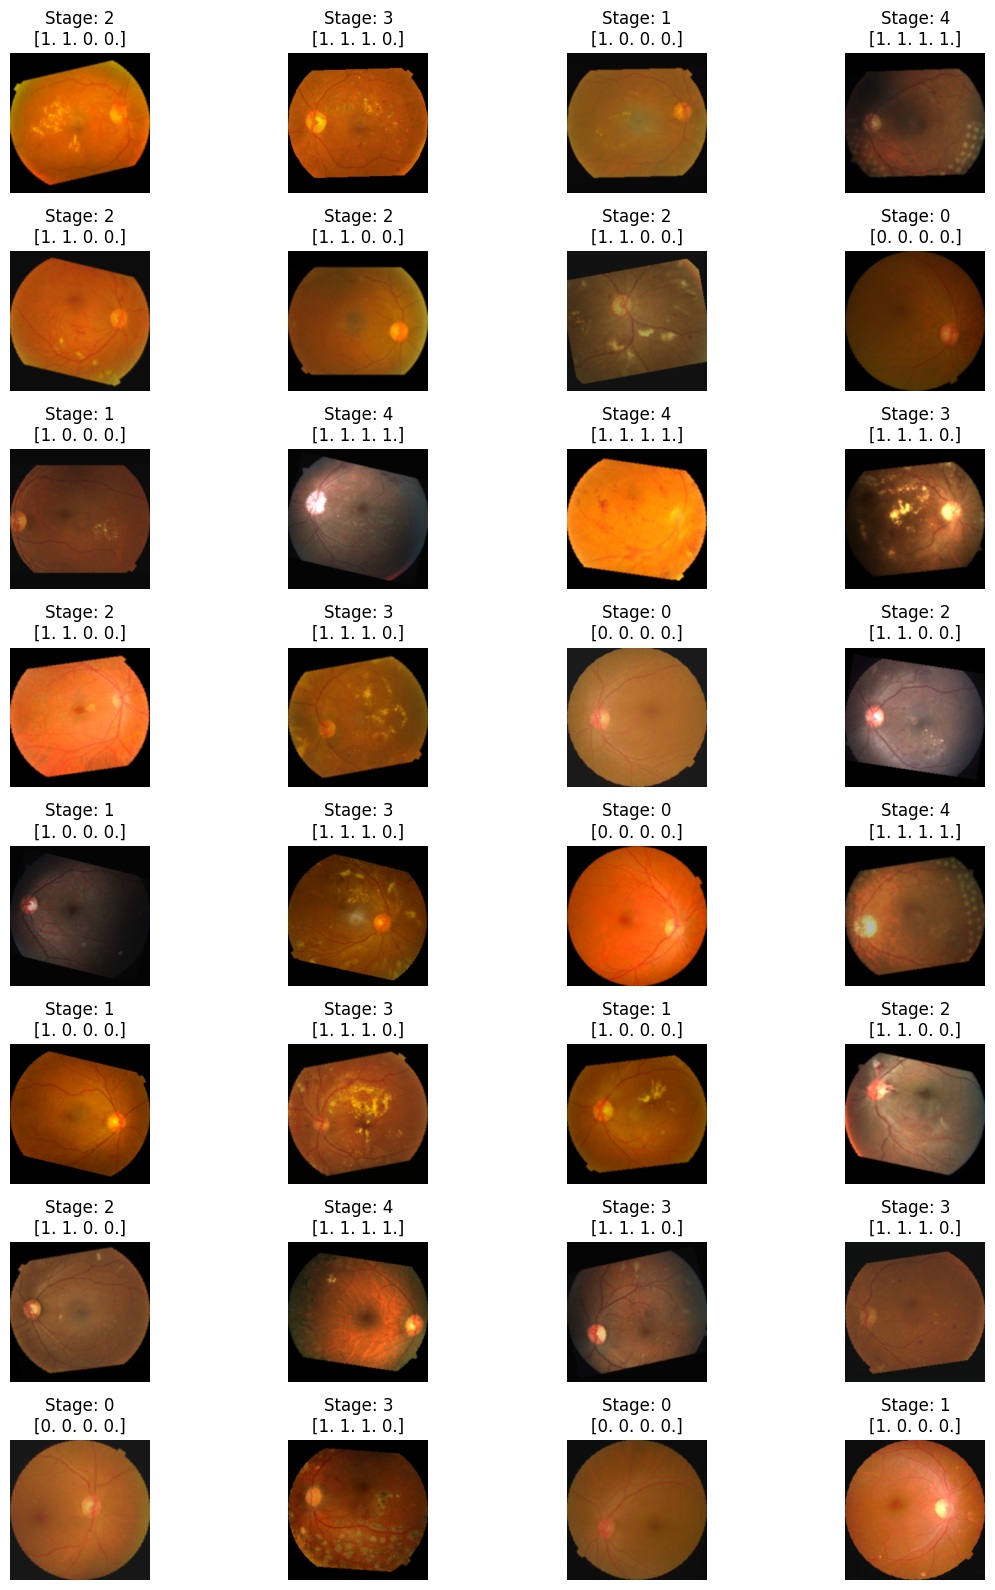

In [39]:
# visualizing one whole batch, transformations are visible in the images
# modified for ordinal

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

figs, axes = plt.subplots(8, 4, figsize=(12, 16))
axes = axes.flatten()

for i in range(len(images)):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)

    # Get ordinal label vector
    threshold_vec = labels[i].cpu().numpy()

    # Convert thresholds to stage (sum of ones)
    stage = int(threshold_vec.sum())

    axes[i].set_title(f"Stage: {stage}\n{threshold_vec}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


#### Swin Transformer

In [25]:
# We configure it for 5 classes (0: No DR, 1: Mild, 2: Moderate, 3: Severe, 4: Proliferative)
configuration = SwinConfig(
    image_size=224, 
    num_channels=3, 
    num_labels=5
)

# Load pretrained weights from Microsoft's Swin-Tiny
model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224", 
    config=configuration, 
    ignore_mismatched_sizes=True
)
model.to(device)        

Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
              (attention): SwinAttention(
                (self): SwinSelfAttention(
                  (query): Linear(in_features=96, out_features=96, bias=True)
                  (key): Linear(in_features=96, out_features=96, bias=True)
                  (value): Linear(in_features=96, out_features=96, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )
                (output): SwinSelfOutput(
        

In [55]:
optimizer = torch.optim.AdamW(model.parameters(), lr = 5e-5, weight_decay = 1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=20)
criterion = torch.nn.CrossEntropyLoss()

In [56]:
num_epochs = 15
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        logits = outputs.logits
        
        loss = criterion(logits, labels)
        
        loss.backward()        
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (i + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

    train_acc = 100 * correct / total
    
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            logits = outputs.logits
            
            loss = criterion(logits, labels)
            val_loss += loss.item()
             
            _, predicted = torch.max(logits.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    print(f"--- Epoch {epoch+1} Summary: Train Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}% ---")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_swin_dr_model.pth')
        print(f'Best model saved with validation accuracy of {val_acc:.2f}%')
        
print("Swin-V2 Training Test Complete.")

Epoch [1/15], Step [10/92], Loss: 1.4322
Epoch [1/15], Step [20/92], Loss: 1.1272
Epoch [1/15], Step [30/92], Loss: 1.0660
Epoch [1/15], Step [40/92], Loss: 1.1706
Epoch [1/15], Step [50/92], Loss: 1.1477
Epoch [1/15], Step [60/92], Loss: 1.0349
Epoch [1/15], Step [70/92], Loss: 0.8119
Epoch [1/15], Step [80/92], Loss: 1.0834
Epoch [1/15], Step [90/92], Loss: 0.8004
--- Epoch 1 Summary: Train Loss: 1.0621, Train Acc: 53.70%, Val Acc: 78.99% ---
Best model saved with validation accuracy of 78.99%
Epoch [2/15], Step [10/92], Loss: 0.9581
Epoch [2/15], Step [20/92], Loss: 0.8998
Epoch [2/15], Step [30/92], Loss: 1.1230
Epoch [2/15], Step [40/92], Loss: 0.6766
Epoch [2/15], Step [50/92], Loss: 1.2111
Epoch [2/15], Step [60/92], Loss: 0.6583
Epoch [2/15], Step [70/92], Loss: 0.6950
Epoch [2/15], Step [80/92], Loss: 0.8786
Epoch [2/15], Step [90/92], Loss: 0.5498
--- Epoch 2 Summary: Train Loss: 0.7887, Train Acc: 68.56%, Val Acc: 73.26% ---
Epoch [3/15], Step [10/92], Loss: 0.5688
Epoch [3/

In [26]:
model.load_state_dict(torch.load('best_swin_dr_model.pth'))
model

C:\Users\Ashraf\AppData\Local\Temp\ipykernel_23560\1324539173.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_swin_dr_model.pth'))

SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
              (attention): SwinAttention(
                (self): SwinSelfAttention(
                  (query): Linear(in_features=96, out_features=96, bias=True)
                  (key): Linear(in_features=96, out_features=96, bias=True)
                  (value): Linear(in_features=96, out_features=96, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )
                (output): SwinSelfOutput(
        

In [19]:
train_labels = pd.read_csv(r'D:\B. Disease Grading\2. Groundtruths\a. IDRiD_Disease Grading_Training Labels.csv')
train_labels = train_labels[['Image name', 'Retinopathy grade']]
test_labels = pd.read_csv(r'D:\B. Disease Grading\2. Groundtruths\b. IDRiD_Disease Grading_Testing Labels.csv')
test_labels = test_labels[['Image name', 'Retinopathy grade']]

all_labels = pd.concat([train_labels, test_labels], ignore_index=True)

In [20]:
train_imgs = r'D:\B. Disease Grading\1. Original Images\a. Training Set'
test_imgs = r'D:\B. Disease Grading\1. Original Images\b. Testing Set'

def add_paths(df, img_dir):
    df['full_path'] = df['Image name'].apply(lambda x: os.path.join(img_dir, x + '.jpg'))
    return df

train_labels = add_paths(train_labels, train_imgs)
test_labels = add_paths(test_labels, test_imgs)
all_data = pd.concat([train_labels, test_labels], ignore_index=True)

In [21]:
all_data.head()

,Image name,Retinopathy grade,full_path
0,IDRiD_001,3,D:\B. Disease Grading\1. Original Images\a. Tr...
1,IDRiD_002,3,D:\B. Disease Grading\1. Original Images\a. Tr...
2,IDRiD_003,2,D:\B. Disease Grading\1. Original Images\a. Tr...
3,IDRiD_004,3,D:\B. Disease Grading\1. Original Images\a. Tr...
4,IDRiD_005,4,D:\B. Disease Grading\1. Original Images\a. Tr...


In [22]:
cross_dataset = IDRiDDataset(all_data, transform=transform_val)
cross_loader = DataLoader(cross_dataset, batch_size=32, shuffle = False)

In [23]:
print(len(cross_dataset))

516


In [27]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in cross_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs.logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f'Cross Dataset accuracy: {100 * correct / total:.2f}%')

Cross Dataset accuracy: 54.65%


In [65]:
print(all_data['Retinopathy grade'].value_counts())

Retinopathy grade
2    168
0    168
3     93
4     62
1     25
Name: count, dtype: int64


In [66]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in cross_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.logits, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds))

[[129  33   4   0   2]
 [ 16   9   0   0   0]
 [ 25  23 110   5   5]
 [  2   3  64   9  15]
 [  2   1  24  10  25]]
              precision    recall  f1-score   support

           0       0.74      0.77      0.75       168
           1       0.13      0.36      0.19        25
           2       0.54      0.65      0.59       168
           3       0.38      0.10      0.15        93
           4       0.53      0.40      0.46        62

    accuracy                           0.55       516
   macro avg       0.46      0.46      0.43       516
weighted avg       0.56      0.55      0.53       516

